<a href="https://colab.research.google.com/github/eulaia/pibic-audiodescricao-llms/blob/main/Qwen2_5_VL_7B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 15.5 MB/s eta 0:00:00
Mounted at /content/drive
GPU disponível: True
GPU: Tesla T4

Carregando modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Modelo carregado!

RELATÓRIO DE GERAÇÃO DE AUDIODESCRIÇÃO
Data: 06/07/2026
Horário: 01:07:24
Modelo: Qwen/Qwen2.5-VL-7B-Instruct
Quantidade de imagens: 3

Processando: foto1.jpg


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


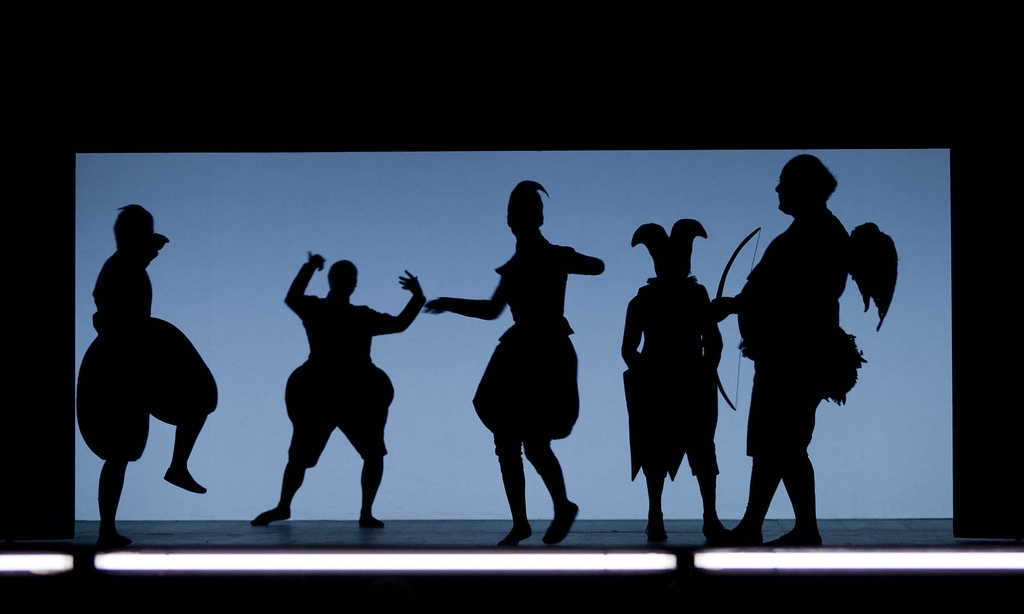


Descrição gerada:

A imagem apresenta uma série de silhuetas humanas em movimento, destacando-se contra um fundo azul claro. O foco principal são cinco figuras que parecem estar dançando ou realizando uma performance teatral. A perspectiva da foto é frontal, capturando os personagens de frente para o espectador. O enquadramento é amplo, incluindo todos os cinco indivíduos em um plano geral, permitindo visualizar suas posturas e movimentos. O fundo azul claro proporciona contraste suficiente para destacar as silhuetas das figuras, enquanto a iluminação é direcionada para elas, tornando-os mais visíveis. Não há informações adicionais sobre o local ou a época fornecidas na imagem.


Processando: foto2.jpg


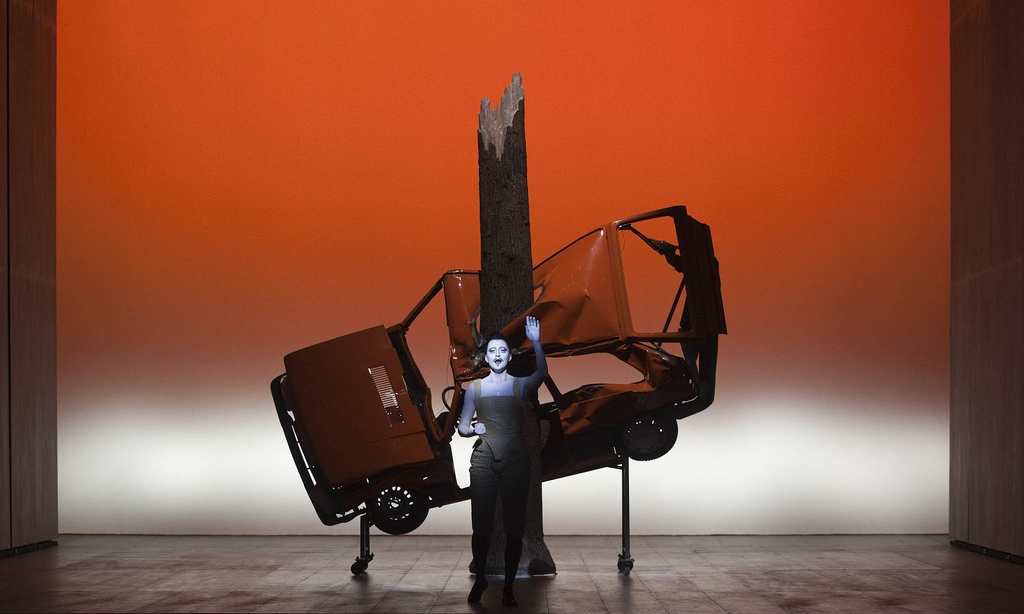


Descrição gerada:

A imagem apresenta uma figura humana centralizada, com os braços erguidos, em uma pose dinâmica. O principal objeto da imagem é um estranho dispositivo mecânico, que parece ser uma combinação de uma cadeira e um computador antigo, montado em rodas. Este dispositivo está inclinado para trás, com um pedaço de madeira verticalmente inserido entre ele e a figura humana. A perspectiva da foto é frontal, capturando a cena em um plano médio, onde tanto a figura quanto o objeto mecânico são visíveis em sua totalidade. Os elementos principais estão posicionados de forma a criar uma sensação de equilíbrio instável, com a figura humana aparentemente sustentando o dispositivo. O fundo é uma parede laranja, que proporciona um contraste vibrante com a cena central. A iluminação é direta e focada, destacando claramente os elementos da imagem e criando sombras que contribuem para a atmosfera dramática. Não há informações adicionais sobre o local ou a época fornecidas na imagem.


P

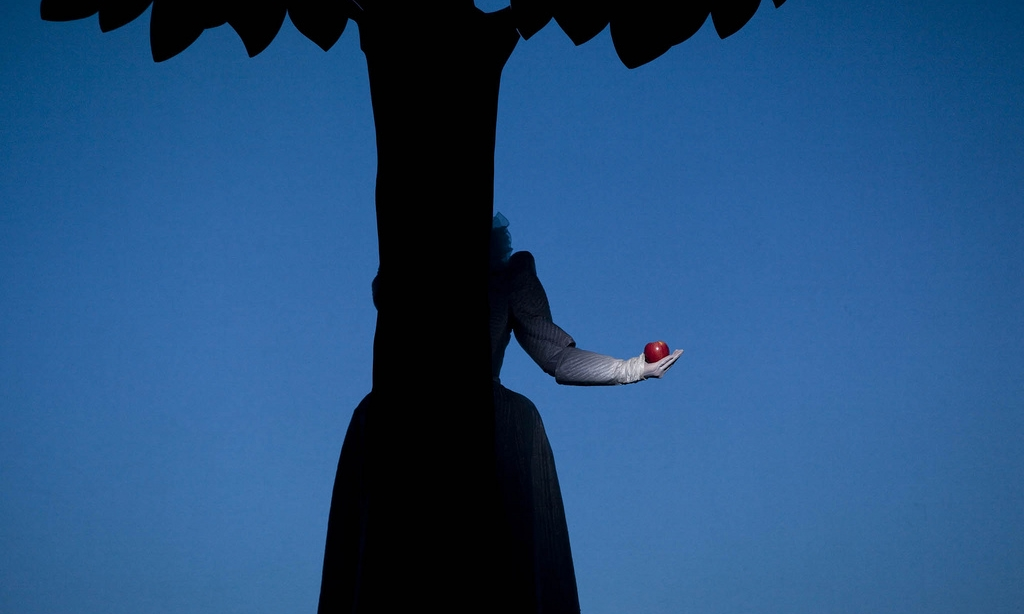


Descrição gerada:

A imagem apresenta uma silhueta de uma figura feminina, vestida com um traje longo e elegante, segurando uma maçã vermelha na mão direita. A perspectiva da foto é de frente, capturando a figura de forma frontal contra um fundo azul uniforme. O enquadramento é centrado na figura, destacando-a claramente contra o fundo. O plano de fundo é simples e monocromático, contribuindo para uma atmosfera minimalista e focada na figura. A iluminação é baixa, criando sombras profundas que enfatizam a silhueta da figura, tornando-a o elemento mais destacado da imagem. Não há contexto adicional fornecido sobre local ou época.


Processamento finalizado.


In [ ]:
!pip install -q transformers accelerate bitsandbytes qwen-vl-utils

import os
import torch
from datetime import datetime
from PIL import Image

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig
)

from google.colab import drive
from IPython.display import display

try:
    drive.mount("/content/drive", force_remount=True)
except Exception:
    try:
        !fusermount -u /content/drive
    except Exception:
        pass
    drive.mount("/content/drive", force_remount=True)

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
FOLDER_PATH = "/content/drive/MyDrive/Imagens"

PROMPT = """
Descreva a imagem de maneira objetiva e concisa, com foco em facilitar a interpretação
por um leitor de audiodescrição. Inclua os seguintes elementos:
Foco Principal: Identifique o principal sujeito ou objeto da imagem. Perspectiva da Foto:
Descreva a perspectiva da foto (ex: de frente, de lado, de cima, etc.) e o tipo de plano (ex: plano
geral, plano médio, close-up, etc.). Enquadramento: Explique como os elementos principais
estão posicionados e enquadrados na imagem. Plano de Fundo: Descreva o que está no fundo da
imagem e como ele contribui para a cena. Iluminação: Explique a iluminação da cena e como ela
afeta a percepção dos elementos na imagem. Contexto (se fornecido): Inclua detalhes sobre o
local e a época, se disponíveis. Preciso que a resposta seja no formato de parágrafo completo e
coerente, não faça em partes.
"""

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nCarregando modelo...")

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print("Modelo carregado!")

def gerar_descricao(imagem):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": imagem},
                {"type": "text", "text": PROMPT}
            ]
        }
    ]

    texto = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[texto],
        images=[imagem],
        padding=True,
        return_tensors="pt"
    )

    device = next(model.parameters()).device

    inputs = {
        chave: valor.to(device)
        for chave, valor in inputs.items()
    }

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=False
    )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs["input_ids"], generated_ids)
    ]

    resposta = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return resposta.strip()

def main():
    if not os.path.exists(FOLDER_PATH):
        raise FileNotFoundError(f"Pasta não encontrada: {FOLDER_PATH}")

    imagens = [
        arquivo
        for arquivo in os.listdir(FOLDER_PATH)
        if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    data_atual = datetime.now()

    print("\nRELATÓRIO DE GERAÇÃO DE AUDIODESCRIÇÃO")
    print(f"Data: {data_atual.strftime('%d/%m/%Y')}")
    print(f"Horário: {data_atual.strftime('%H:%M:%S')}")
    print(f"Modelo: {MODEL_ID}")
    print(f"Quantidade de imagens: {len(imagens)}")
    print("=" * 100)

    for arquivo in imagens:
        caminho = os.path.join(FOLDER_PATH, arquivo)

        print(f"\nProcessando: {arquivo}")

        try:
            imagem = Image.open(caminho)
            descricao = gerar_descricao(imagem)

            display(imagem)

            print("\nDescrição gerada:\n")
            print(descricao)

        except Exception as erro:
            print(f"Erro ao processar {arquivo}: {erro}")

        print("\n" + "=" * 100)

    print("\nProcessamento finalizado.")

main()